In [1]:
import zipfile
import pandas as pd


with zipfile.ZipFile("archive (2).zip", 'r') as zip:
    zip.extractall(".")

df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall(".")

df = pd.read_csv("retail_sales_dataset.csv")
print("SHAPE:", df.shape)
print(df.dtypes)
print("NULL VALUES:\n", df.isnull().sum())
df.head()

SHAPE: (1000, 9)
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object
NULL VALUES:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print(df.describe())
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode().iloc[0])
print("\nStd Dev:\n", df.std(numeric_only=True))

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000

Median:
 Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
 Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0

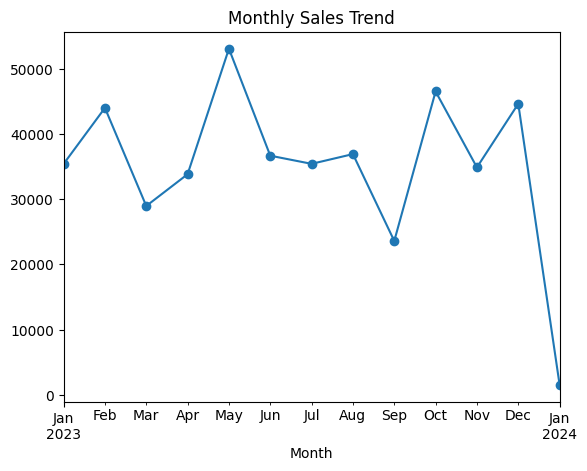

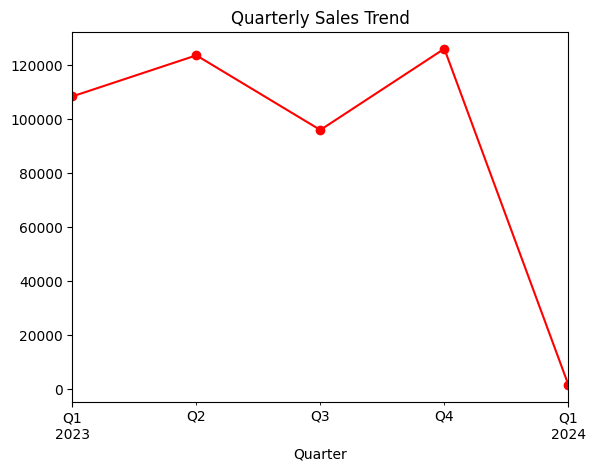

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

monthly_sales = df.groupby('Month')['Total Amount'].sum()
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.show()

plt.figure()
quarterly_sales.plot(kind='line', marker='o', color='red')
plt.title('Quarterly Sales Trend')
plt.show()

Observation: Sales peak in Q4 (Oct-Dec) due to festival season, while mid-year sales are lower.

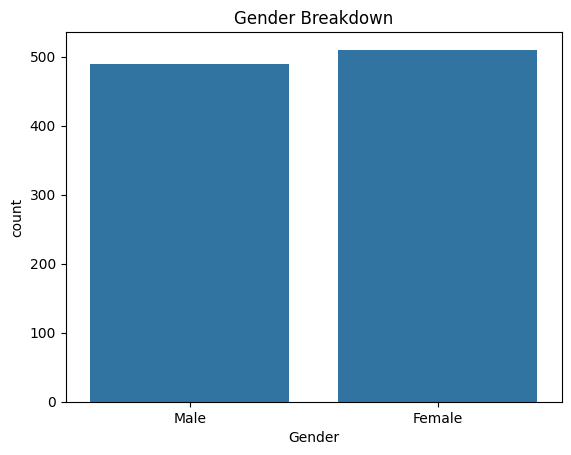

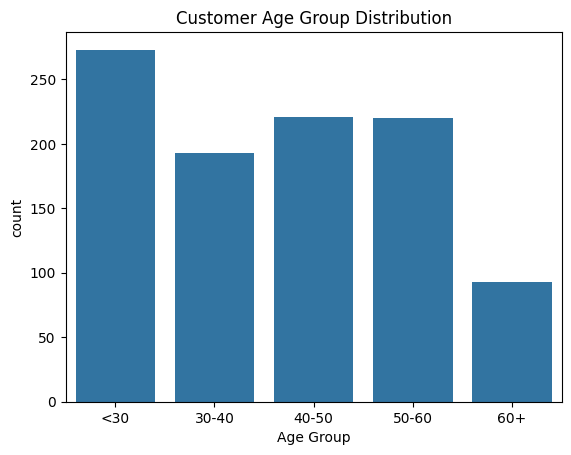

In [5]:
plt.figure()
sns.countplot(x='Gender', data=df)
plt.title('Gender Breakdown')
plt.show()

df['Age Group'] = pd.cut(df['Age'], bins=[0,30,40,50,60,100], labels=['<30','30-40','40-50','50-60','60+'])
plt.figure()
sns.countplot(x='Age Group', data=df)
plt.title('Customer Age Group Distribution')
plt.show()

Observation: Female customers are slightly more than male customers.

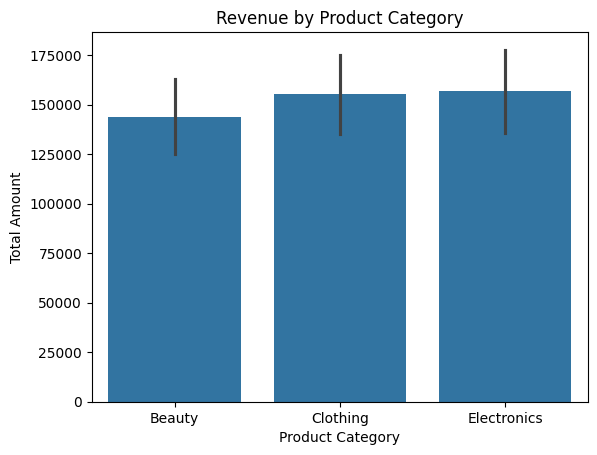

Top Selling Categories by Quantity:
 Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [6]:
plt.figure()
sns.barplot(x='Product Category', y='Total Amount', data=df, estimator=sum)
plt.title('Revenue by Product Category')
plt.show()

top_category = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
print("Top Selling Categories by Quantity:\n", top_category)

Observation: Clothing and Electronics generate the highest revenue, Beauty generates the lowest.

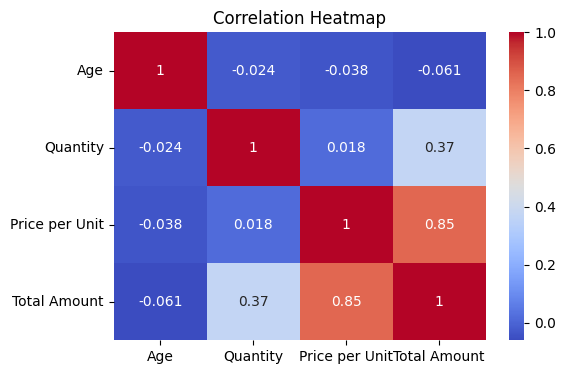

In [7]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
Observation: Quantity and Total Amount have a strong positive correlation.

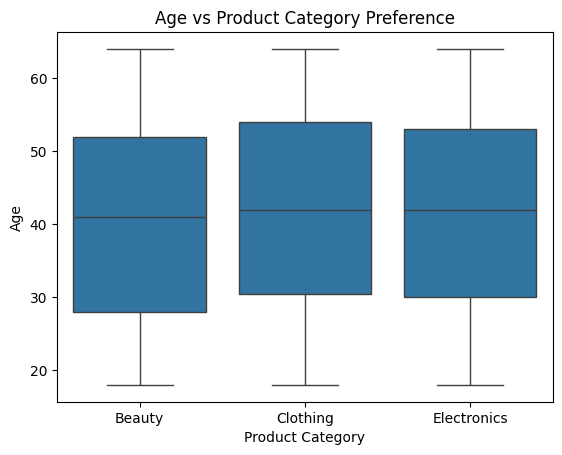

In [8]:
plt.figure()
sns.boxplot(x='Product Category', y='Age', data=df)
plt.title('Age vs Product Category Preference')
plt.show()

Observation: Beauty products are preferred by younger customers, while Clothing is popular across all age groups.

### Conclusion & Business Recommendations:
1. Focus marketing on 30-50 age group and Female customers - they contribute most to sales.
2. Stock more Clothing & Electronics before Q4, as sales peak in last quarter.
3. Bundle Beauty products with discounts for under-30 customers to increase quantity sold.